# Lesson 3: Agentic Search

In [ ]:
# -----------------------------------------------------------
# 步骤 1: 导入必要的库并加载环境变量
# -----------------------------------------------------------
from dotenv import load_dotenv
import os
 # Tavily搜索API客户端
from tavily import TavilyClient

# load environment variables from .env file
_ = load_dotenv()

# 连接到Tavily API
# Tavily是一个专为AI代理设计的搜索API
# 特点：
# - 返回结构化数据（不是原始HTML）
# - 专为LLM优化，提供简洁准确的答案
# - 比普通搜索引擎更适合AI使用
client = TavilyClient(api_key=os.environ.get("TAVILY_API_KEY"))

In [2]:
# -----------------------------------------------------------
# 步骤 2: 执行Tavily搜索并获取答案
# -----------------------------------------------------------
# 运行搜索：查询Nvidia Blackwell GPU信息
result = client.search("What is in Nvidia's new Blackwell GPU?",  # 搜索查询
                       include_answer=True   # 要求返回简洁、准确的答案  False: 只返回搜索结果列表（需要自己处理）
                       )

# 打印搜索结果中的答案部分
result["answer"]

# Tavily搜索的返回结构说明
# {
#   "query": "搜索的原始问题",
#   "follow_up_questions": ["可能的后续问题"],
#   "answer": "Tavily生成的简洁答案",  # ← 我们获取的就是这个
#   "images": ["相关图片链接"],
#   "results": [  # 详细的搜索结果列表
#     {
#       "title": "网页标题",
#       "url": "网页URL",
#       "content": "网页内容摘要",
#       "score": 0.99,  # 相关性评分
#       "raw_content": "原始内容（可能很长）"
#     },
#     ...
#   ],
#   "response_time": 1.5,  # 响应时间（秒）
#   "request_id": "唯一请求ID"
# }


'The new Blackwell GPU features fifth-generation NVLink, FP4 precision, and a massive 15 petaFLOPS performance. It uses a dual-reticle design and HBM3E memory for AI applications. It supports up to 576 GPUs.'

## Regular search 常规搜索方法讲解

In [ ]:
# -----------------------------------------------------------
# 常规搜索示例（使用DuckDuckGo搜索功能）
# -----------------------------------------------------------

# -----------------------------------------------------------
# 步骤 1: 定义搜索内容
# -----------------------------------------------------------
# 选择城市（可以改成你自己的城市！）
city = "San Francisco"

# 翻译
# 目前{city}的天气如何？
# 我今天应该去那里吗？
query = f"""
    what is the current weather in {city}?
    Should I travel there today?
    "weather.com"
"""

# 为什么限定"weather.com"？
# - 限定特定网站可以提高搜索结果的相关性
# - 对于天气查询，weather.com是权威来源
# - 减少无关结果，提高后续处理效率


### 常见DuckDuckGo搜索语法

|语法|作用|示例|
|---|---|---|
|`"site:example.com"`|仅搜索指定网站|`"天气 site:weather.com"`|
|`"after:2023-01-01"`|搜索特定日期后的内容|`"新闻 after:2023-01-01"`|
|`"filetype:pdf"`|搜索特定文件类型|`"报告 filetype:pdf"`|
|`"intitle:weather"`|标题包含关键词|`"intitle:weather forecast"`|


> Note: search was modified to return expected results in the event of an exception. High volumes of student traffic sometimes cause rate limit exceptions.

> 注意：已修​​改搜索规则，以便在出现异常情况时返回预期结果。学生流量高峰有时会导致速率限制异常。

In [ ]:
# -----------------------------------------------------------
# 步骤 2: 实现DuckDuckGo搜索功能
# -----------------------------------------------------------
import requests  # 用于发送HTTP请求
from bs4 import BeautifulSoup  # 用于解析HTML（网页抓取）
from ddgs import DDGS  # DuckDuckGo搜索API客户端
import re  # 正则表达式库

ddg = DDGS()

def search(query, max_results=6):
    """
    使用DuckDuckGo搜索并返回结果链接
    
    :param query: 搜索查询
    :param max_results: 最大返回结果数
    :return: 网页URL列表
    """
    try:
        # 执行搜索，获取结果
        # ddg.text()是DDGS库的搜索方法
        results = ddg.text(query, max_results=max_results)

        # 从结果中提取URL（results是字典列表）
        # 每个结果格式:
        # [
        #     {
        #         "title": "San Francisco Weather Today",
        #         "href": "https://weather.com/...",
        #         "body": "Current temperature in SF is 65°F...",
        #         # ...其他字段
        #     },
        #     # ...更多结果
        # ]
        return [i["href"] for i in results]
    except Exception as e:
        # 网络请求可能失败（如API限制、网络问题）
        # 优雅处理异常，避免程序崩溃
        print(f"returning previous results due to exception reaching ddg.")
        # 返回预设结果（教学用途，避免API限制问题）
        # 实际应用中应有更完善的降级策略
        results = [ # cover case where DDG rate limits due to high deeplearning.ai volume
            "https://weather.com/weather/today/l/USCA0987:1:US",
            "https://weather.com/weather/hourbyhour/l/54f9d8baac32496f6b5497b4bf7a277c3e2e6cc5625de69680e6169e7e38e9a8",
        ]
        return results

# 执行搜索并打印结果URL
for i in search(query):
    print(i)

https://duckduckgo.com/y.js?ad_domain=kayak.sg&ad_provider=bingv7aa&ad_type=txad&click_metadata=Peq4qFCgveX0AwbIZYL4M4RqGaU86-Qx1ARW9Wp95jED-JGK5XoLbXr-ee-PgAO_85E9dV71Lxn-8mkTz2FvbvP4pdLtZADeRm-hRPgtrJcH72w2T9Tivf-pz5_K7K7M.4BnYaVoP-p0kxu0OugAzLQ&rut=dc761cffb1a66a6f8f0d12cc9cb733b82464e8fa655479d736e68372f260f068&u3=https://www.bing.com/aclick?ld=e8X6D8_wNNJwBfi5eL6u4EtDVUCUxlmDzpmJrnZIbs2AJXhMlUY8QpBvn6UeU-zJ406-dBKHX140GM_9ieJ5a_18sUSc6qVMFMmYPlSyjJWSsU1fyUSdn87eESzaaqTH9Vgo1UDSqvB4mwC8SvcR5q4sYI6D8E7ZfxGxZQV3KhMI36-iZemh3OUZrioaCEdNvw-DHB6TznKOSOpMIW1OWyCWpHYfY&u=aHR0cHMlM2ElMmYlMmZ3d3cua2F5YWsuc2clMmZzZW1pJTJmYmluZ2Fkc3NlYXJjaCUyZmZsaWdodF9kZXN0aW5hdGlvbiUyZjEzODUyJTJmZW4uaHRtbCUzZm10JTNkYiUyNmJtdCUzZGJiJTI2b2lpZCUzZDc4NjE1NDYxOTI2MTY2JTI2YWlkJTNkMTI1Nzg0MTkxNDIyMzg3MCUyNmFkaWQlM2Q3ODYxNTI3MjkzMDc1OCUyNnBpZCUzZCUyNnRpZCUzZGt3ZC03ODYxNTQ2MTkyNjE2NiUzYWxvYy0xNjQlMjZkJTNkYyUyNm4lM2RzJTI2Y21waWQlM2QzOTY3OTkzMDglMjZtc2Nsa2lkJTNkMTg4NjBhNDRkYjFlMTJjYjk5MmE2MzUxNTVkMTE1MWElMjZ1dG1fc291c

In [ ]:
# -----------------------------------------------------------
# 步骤 3: 实现网页内容抓取功能
# -----------------------------------------------------------
def scrape_weather_info(url):
    """
    从指定URL抓取天气信息
    
    :param url: 要抓取的网页URL
    :return: 网页内容的BeautifulSoup对象或错误信息
    """
    # 检查URL是否为空
    if not url:
        return "Weather information could not be found."
    
    # 设置请求头（模拟浏览器）
    # - 有些网站会拒绝非浏览器的请求
    # - 设置User-Agent可以避免被网站屏蔽
    headers = {'User-Agent': 'Mozilla/5.0'}
    # 发送HTTP GET请求获取网页内容
    response = requests.get(url, headers=headers)
    # 检查HTTP响应状态码
    # - 200: 请求成功
    # - 404: 页面未找到
    # - 500: 服务器错误
    if response.status_code != 200:
        return "Failed to retrieve the webpage."

    # 使用BeautifulSoup解析HTML
    soup = BeautifulSoup(response.text, 'html.parser')
    return soup


> Note: This produces a long output, you may want to right click and clear the cell output after you look at it briefly to avoid scrolling past it.

In [7]:
# -----------------------------------------------------------
# 步骤 4: 执行搜索并抓取该URL的网页内容
# -----------------------------------------------------------
# 使用DuckDuckGo搜索获取第一个结果的URL
# use DuckDuckGo to find websites and take the first result
url = search(query)[0]

# 抓取该URL的网页内容
# scrape first wesbsite
soup = scrape_weather_info(url)

print(f"Website: {url}\n\n")
print(str(soup.body)[:50000]) # limit long outputs 只显示前50000字符

Website: https://weather.com/weather/today/l/San+Francisco+CA+USCA0987:1:US


<body><div class="appWrapper DaybreakLargeScreen LargeScreen lightTheme twcTheme DaybreakLargeScreen--appWrapper--ZkDop" id="appWrapper"><div class="region-sidebarNavigation regionSidebarNavigation"><div class="removeIfEmpty" id="WxuSidebarNavigation-sidebarNavigation-sidebar-nav-injection"><div aria-hidden="false" class="SidebarNavigation--sidebarWrapper--v+g78"><nav aria-label="Site Navigation Links" class="SidebarNavigation--sidebar--A5yHr" data-testid="sidebar-navigation"><div class="SidebarNavigation--sidebarHeader--bMAxo"><button class="SidebarNavigation--overlayControlButton--cSFvn openSidebarOverlayButton" tabindex="0" type="button"><span class="Icon--iconWrapper--vSeDL"><svg class="Icon--icon--ySD-o" fill="none" height="24" name="hamburger" viewbox="0 0 24 24" width="24" xmlns="http://www.w3.org/2000/svg">
<title>Hamburger</title>
<path d="M20 16C20.5523 16 21 16.4477 21 17C21 17.5523 20.5523 18 20 1

In [8]:
# -----------------------------------------------------------
# 步骤 5: 从解析的HTML中提取文本内容
# -----------------------------------------------------------
# extract text
weather_data = []
# 查找所有标题和段落标签
for tag in soup.find_all(['h1', 'h2', 'h3', 'p']):
    # 获取标签文本，用空格替换内部换行，去除首尾空格
    text = tag.get_text(" ", strip=True)
    weather_data.append(text)

# 将所有提取的文本合并为一个字符串，用换行分隔
# combine all elements into a single string
weather_data = "\n".join(weather_data)

# 使用正则表达式将多个连续空白字符替换为单个空格
# \s+ 匹配一个或多个空白字符（空格、制表符、换行等）
# remove all spaces from the combined text
weather_data = re.sub(r'\s+', ' ', weather_data)
    
print(f"Website: {url}\n\n")
print(weather_data)

# 文本清理为什么重要？
# 1. 原始HTML包含大量格式化空白
# 2. 连续换行/空格影响后续处理
# 3. 统一格式便于LLM理解和处理
# re.sub(r'\s+', ' ', text)是文本清理的常用技巧

Website: https://weather.com/weather/today/l/San+Francisco+CA+USCA0987:1:US


Recents Weather Forecasts Radar & Maps News & Media Products & Account Lifestyle Specialty Forecasts Downtown, San Francisco, California High Wind Warning Weather Today in Downtown, San Francisco, California 6:47 am 5:00 pm Radar Rain Rain possible around 12:45 AM. Locally heavy rainfall possible. Hourly Weather - Downtown, San Francisco, California Now Showers 1 am Few Showers 2 am Rain 3 am Rain Don't Miss Travel 10 Day Weather - Downtown, San Francisco, California Tonight Night Rain showers this evening becoming steadier and heavier overnight. Low 62F. Winds SSE at 15 to 25 mph. Chance of rain 100%. Rainfall near an inch. Locally heavy rainfall possible. Thu 13 Day A steady rain in the morning. Showers continuing in the afternoon. High 64F. Winds SSW at 10 to 20 mph. Chance of rain 100%. Rainfall near a half an inch. Locally heavy rainfall possible. Night Overcast with rain showers at times. Low 54F. Winds

## Agentic Search  代理式搜索讲解

In [9]:
# -----------------------------------------------------------
# 步骤 1: 使用Tavily进行Agentic Search（智能搜索）
# -----------------------------------------------------------
# 运行Tavily搜索（只获取1个结果）
result = client.search(query, max_results=1)

# 获取第一个搜索结果的内容
data = result["results"][0]["content"]

print(data)

# 普通搜索：
#   1. 发送查询 → 2. 获取链接 → 3. 抓取网页 → 4. 提取信息
# Agentic Search（Tavily）：
#   1. 发送查询 → 2. 直接获取结构化答案
# 优势：
#   - 步骤更少，效率更高
#   - 结果更精准（专为AI优化）
#   - 不需要处理HTML解析
# 适合需要快速获取答案的场景

{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1763020538, 'localtime': '2025-11-12 23:55'}, 'current': {'last_updated_epoch': 1763019900, 'last_updated': '2025-11-12 23:45', 'temp_c': 19.4, 'temp_f': 66.9, 'is_day': 0, 'condition': {'text': 'Partly cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/night/116.png', 'code': 1003}, 'wind_mph': 13.4, 'wind_kph': 21.6, 'wind_degree': 157, 'wind_dir': 'SSE', 'pressure_mb': 1012.0, 'pressure_in': 29.87, 'precip_mm': 0.05, 'precip_in': 0.0, 'humidity': 71, 'cloud': 75, 'feelslike_c': 19.4, 'feelslike_f': 66.9, 'windchill_c': 16.0, 'windchill_f': 60.7, 'heatindex_c': 16.0, 'heatindex_f': 60.7, 'dewpoint_c': 13.6, 'dewpoint_f': 56.4, 'vis_km': 16.0, 'vis_miles': 9.0, 'uv': 0.0, 'gust_mph': 24.0, 'gust_kph': 38.7}}


In [10]:
# -----------------------------------------------------------
# 步骤 2: 解析和美化JSON结果
# -----------------------------------------------------------
import json
from pygments import highlight, lexers, formatters

# 解析JSON数据
# 注意：Tavily返回的内容可能用单引号，而JSON要求双引号
# 所以先替换单引号为双引号
parsed_json = json.loads(data.replace("'", '"'))

# 格式化JSON（缩进4个空格，更易读）
formatted_json = json.dumps(parsed_json, indent=4)
# 使用语法高亮美化JSON输出（在终端中显示彩色）
colorful_json = highlight(
    formatted_json,
    lexers.JsonLexer(),  # 指定JSON语法
    formatters.TerminalFormatter()  # 终端输出格式
)

print(colorful_json)

# 为什么要格式化JSON？
# 1. 原始JSON通常是一行，难以阅读
# 2. 缩进和高亮使结构清晰可见
# 3. 便于调试和理解数据结构
# json.dumps(..., indent=4)是标准做法


{
    "location": {
        "name": "San Francisco",
        "region": "California",
        "country": "United States of America",
        "lat": 37.775,
        "lon": -122.4183,
        "tz_id": "America/Los_Angeles",
        "localtime_epoch": 1763020538,
        "localtime": "2025-11-12 23:55"
    },
    "current": {
        "last_updated_epoch": 1763019900,
        "last_updated": "2025-11-12 23:45",
        "temp_c": 19.4,
        "temp_f": 66.9,
        "is_day": 0,
        "condition": {
            "text": "Partly cloudy",
            "icon": "//cdn.weatherapi.com/weather/64x64/night/116.png",
            "code": 1003
        },
        "wind_mph": 13.4,
        "wind_kph": 21.6,
        "wind_degree": 157,
        "wind_dir": "SSE",
        "pressure_mb": 1012.0,
        "pressure_in": 29.87,
        "precip_mm": 0.05,
        "precip_in": 0.0,
        "humidity": 71,
        "cloud": 75,
        "feelslike_c": 19.4,
        "feelslike_f": 66.9,
        "windchill_c": 16.0,


<img src="./google_sample.png" width="800" height="600">

## 整体流程图解
### 常规搜索流程（DuckDuckGo）
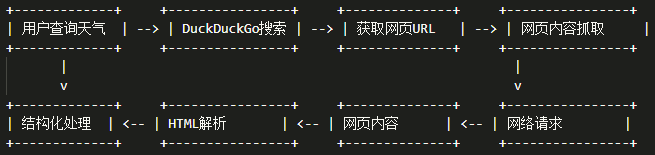

### Agentic Search流程（Tavily）
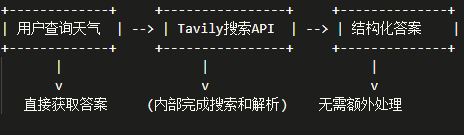

### 1. 两种搜索方式对比

|特性|常规搜索（DuckDuckGo）|Agentic Search（Tavily）|
|---|---|---|
|**步骤**|多步骤（搜索→抓取→解析）|单步骤（直接获取答案）|
|**复杂度**|高（需处理HTML、异常等）|低（API直接返回结构化数据）|
|**灵活性**|高（可自定义处理逻辑）|中（依赖API返回内容）|
|**适用场景**|需要深度定制处理|快速获取简洁答案|
|**学习价值**|了解网页抓取全流程|体验AI优化的搜索|

#### 2. 为什么Tavily更适合AI Agent？
- **专为LLM设计**：返回简洁、准确的答案，而非原始网页
- **结构化数据**：结果已是JSON格式，无需HTML解析
- **减少步骤**：从"搜索→抓取→解析"简化为"搜索→答案"
- **可靠性高**：处理了API限制、格式化等问题

#### 3. 网页抓取关键步骤
1. **发送请求**：使用`requests.get()`获取网页内容
2. **解析HTML**：用`BeautifulSoup`将HTML转为可操作的对象
3. **提取数据**：通过`find_all()`等方法定位目标内容
4. **清理文本**：去除多余空白，统一格式
5. **结构化处理**：将提取的数据组织为可用格式

#### 4. 安全与最佳实践
- **API密钥管理**：始终使用`.env`文件，不硬编码在代码中
- **异常处理**：网络请求必须用`try-except`包裹
- **请求头设置**：模拟浏览器避免被屏蔽
- **内容清理**：原始网页内容需要清理才能用于LLM
- **降级策略**：当API受限时提供备用方案（如预设URL）